# Data Analysis 

In [116]:
## Dependencies
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import boxcox
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

### 1. Acquiring datasets

In [117]:
# NVIDIA dataset:
nvidia = yf.download("NVDA", start="2020-01-01", end="2026-07-01")
nvidia.columns = nvidia.columns.get_level_values(0)
nvidia.columns.name = None # removing title of column names.
nvidia.reset_index(inplace=True) # resetting index to have date as a column.

nvidia["Date"] = pd.to_datetime(nvidia["Date"]) # date column as Date.
nvidia.head(5)

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2020-01-02,5.963804,5.963804,5.884506,5.934968,237536000
1,2020-01-03,5.868347,5.912098,5.819376,5.844234,205384000
2,2020-01-06,5.892957,5.898177,5.749026,5.775128,262636000
3,2020-01-07,5.964302,6.010041,5.876302,5.921296,314856000
4,2020-01-08,5.975487,6.016752,5.920052,5.960074,277108000


In [118]:
# Semiconductor billing dataset:
sia = pd.read_csv('americas_semiconductor_billings.csv') # one value per month; low granularity compared to nvidia dataset.
sia["Date"] = pd.to_datetime(sia["Date"])
sia.head(5)

/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_12131/2856192465.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sia["Date"] = pd.to_datetime(sia["Date"])


,Date,Value
0,2026-05-31,46.42M
1,2026-04-30,41.53M
2,2026-03-31,40.60M
3,2026-02-28,36.20M
4,2026-01-31,24.63M


In [119]:
# Merging:
merged = pd.merge(
    nvidia,
    sia[["Date", "Value"]],
    on="Date",
    how="left" # keep the all dates form nvidia set.
)

merged["Value"] = merged["Value"].fillna("")

## Output:
display(merged[merged["Value"] != ""].head(5)) # value column filled only at end of month.
display(merged.head(10))

,Date,Close,High,Low,Open,Volume,Value
607,2022-05-31,18.616375,19.142802,18.295334,18.923456,664100000,12.61M
628,2022-06-30,15.117032,15.523902,14.820854,15.318472,686070000,12.10M
671,2022-08-31,15.052211,15.496976,14.917584,15.341408,573710000,11.52M
692,2022-09-30,12.108989,12.601768,12.045147,12.057117,565638000,13.77M
713,2022-10-31,13.463632,13.803789,13.264126,13.743937,486341000,11.69M


,Date,Close,High,Low,Open,Volume,Value
0,2020-01-02,5.963804,5.963804,5.884506,5.934968,237536000,
1,2020-01-03,5.868347,5.912098,5.819376,5.844234,205384000,
2,2020-01-06,5.892957,5.898177,5.749026,5.775128,262636000,
3,2020-01-07,5.964302,6.010041,5.876302,5.921296,314856000,
4,2020-01-08,5.975487,6.016752,5.920052,5.960074,277108000,
5,2020-01-09,6.041113,6.113452,5.987419,6.061746,255112000,
6,2020-01-10,6.073430,6.178581,6.059260,6.148254,316296000,
7,2020-01-13,6.263846,6.288953,6.133836,6.156457,319840000,
8,2020-01-14,6.147011,6.246445,6.133836,6.221089,359088000,
9,2020-01-15,6.104503,6.182061,6.078650,6.159689,263104000,


### 2. Data Inspection

In [120]:
# Inspecting and cleaning time series data

## Date as index in both datasets:
sia.set_index("Date", inplace=True)
nvidia.set_index("Date", inplace=True)


In [121]:
## Duplicates
print(sia.duplicated().sum()) # 1 potential duplicate in sia.
print(nvidia.duplicated().sum())

1
0


In [122]:
sia[sia["Value"].duplicated(keep=False)] # duplicate is just the value in different months; duplicate should NOT be removed.

,Value
Date,
2025-03-31,20.71M
2024-11-30,20.71M


In [123]:
## Null
nvidia.isnull().sum()
sia.isnull().sum()
# NONE

Value    0
dtype: int64

In [124]:
## Differences in time stamps (now, index)
nvidia.index.to_series().diff().value_counts()

Date
1 days    1276
3 days     291
4 days      48
2 days      15
Name: count, dtype: int64

In [125]:
## month-end data from nividia:
nvidia_monthly = nvidia.resample("ME").last()
nvidia_monthly.head(5)

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-31,5.877295,6.076660,5.835532,6.064728,370420000
2020-02-29,6.717552,6.777000,6.014133,6.030798,1133252000
2020-03-31,6.556622,6.850128,6.411113,6.646166,949960000
2020-04-30,7.269989,7.423706,7.256060,7.369731,375916000
2020-05-31,8.830542,8.830542,8.442020,8.511168,745256000


### 2a. Feature Engineering

In [126]:
# turning Value from string to numeric:
sia["Value_num"] = sia["Value"].str.replace("M", "", regex=False)

sia["Value_num"] = pd.to_numeric(sia["Value_num"])

In [127]:
# Lagging by one day:
nvidia["Close_lag1"] = nvidia["Close"].shift(1)
nvidia["Close_lag2"] = nvidia["Close"].shift(2)

sia["Value_lag1"] = sia["Value_num"].shift(1)
sia["Value_lag2"] = sia["Value_num"].shift(2)

In [128]:
# Rolling statistics: helps capture short-term trends
## Rolling averages, e.g.: how mean sales change over a rolling 5-day period?

nvidia["rolling_mean_3"] = nvidia["Close"].rolling(3).mean()
nvidia["rolling_sd_3"] = nvidia["Close"].rolling(3).std()

sia["rolling_mean_3"] = sia["Value_num"].rolling(3).mean()
sia["rolling_sd_3"] = sia["Value_num"].rolling(3).std()

In [129]:
# Expanding Window features:
## For 'cumulative' information
nvidia["expanding_mean"] = nvidia["Close"].expanding().mean() # cumulative/'expanding' mean per row, i.e. mean of row 1, mean of rows 1 and 2, and so on.
sia["expanding_mean"] = sia["Value_num"].expanding().mean()

In [130]:
# % change feature:
nvidia["return"] = nvidia["Close"].pct_change() # pct(%) change in Close value from previous row (lag of 1 is default)
sia["Value_growth"] = sia["Value_num"].pct_change()

In [131]:
# Date component extraction:
nvidia["Year"] = nvidia.index.year
nvidia["Month"] = nvidia.index.month

sia["Year"] = sia.index.year
sia["Month"] = sia.index.month

### 2b. Merging Multi-Source Data

In [132]:
# Merging datasets:

## a common column that captures the year and month (Y-m), by capturing the monthly frequency, i.e. to_period("M")
nvidia["YM"] = nvidia.index.to_period("M")
sia["YM"] = sia.index.to_period("M")

final = pd.merge(nvidia.reset_index(), sia.reset_index(), # turns index (or Date) into a dataset column => required for merging
                 on="YM",
                 how="inner") # keeps the months that appear in both datasets in 'final'

### 3. Transformations

In [133]:
# removing duplicates in both datasets:
nvidia.duplicated(subset="YM").sum() # 1553 of nvidia
sia.duplicated(subset="YM").sum()

nvidia = nvidia.drop_duplicates(subset="YM")
sia = sia.drop_duplicates(subset="YM")

In [134]:
### double check:
nvidia["YM"][~nvidia.duplicated(subset="YM")].head() # ~ negates the mask => the first (non-duplicate) row of each month

Date
2020-01-02    2020-01
2020-02-03    2020-02
2020-03-02    2020-03
2020-04-01    2020-04
2020-05-01    2020-05
Name: YM, dtype: period[M]

In [135]:
# Merging for new final df:
final = pd.merge(nvidia.reset_index(),
                 sia.reset_index(),
                 on="YM",
                 how="inner")

In [136]:
# Transformations: Log, Box-Cox, Differencing
## AIM: To NORMALISE the distribution of data
# Reshape/rescale the data so it meets model assumptions: stabilise variance (e.g. log),
# put features on a comparable scale (normalise/standardise), and remove trend/seasonality
# to make the series stationary => cleaner signal and better-behaved, more accurate models.

########################
# 1. Log Transformation:
final["log_Close"] = np.log(final["Close"])
final["log_Value"] = np.log(final["Value_num"])

# 2. Box-Cox Transformation
## lam (lambda) = the power boxcox picks to best normalise the data (0=log, 0.5=sqrt, 1=no transform).
## boxcox only works on POSITIVE values.
final["boxcox_Close"], lam = boxcox(final["Close"])

# 3. First Differencing
## each value minus the previous one (value[t] - value[t-1]) => removes trend to make the series stationary.
final["diff_Close"] = final["Close"].diff()
final["diff_Value"] = final["Value_num"].diff()

# 4. Seasonal Differencing
## each value minus the one m periods earlier (value[t] - value[t-m]) => removes a repeating seasonal cycle.
final["seasonal_diff_Close"] = final["Close"].diff(12) # yearly difference

## FINAL: drop na rows, for complete dataset
final = final.dropna()

### 4. Forecast Evaluation Metrics

#### Useful for picking up on Anomalies = unexpected drops or spikes in data.

In [137]:
# MAE = Mean Absolute Error; simple metric.
# RMSE = Root Mean of Squared Errors; Punishes big errors.
# MAPE = Mean Absolute Percentage Error; error as a % of actuals, so scale-independent, i.e.: a %, not data units => comparable across differently-sized series.

## Feature Engineering

### 5. Visualizing Trends & Patterns

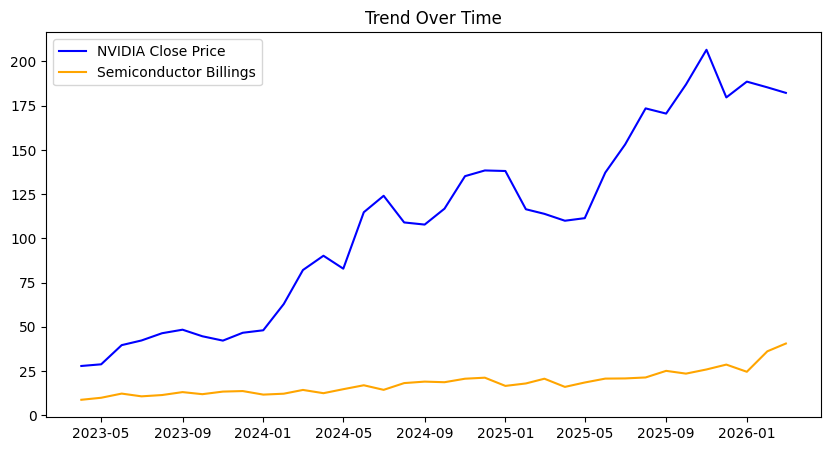

In [138]:
# time series split
## Line Plot:
final['YM'] = final['YM'].dt.to_timestamp() # Y-M is now continuous, so can be plotted on x-axis as a time series.

## OUTPUT:
plt.figure(figsize=(10,5))
plt.plot(final['YM'], final['Close'], label='NVIDIA Close Price', color='blue')
plt.plot(final['YM'], final['Value_num'], label='Semiconductor Billings', color='orange')
plt.legend()
plt.title("Trend Over Time")
plt.show()

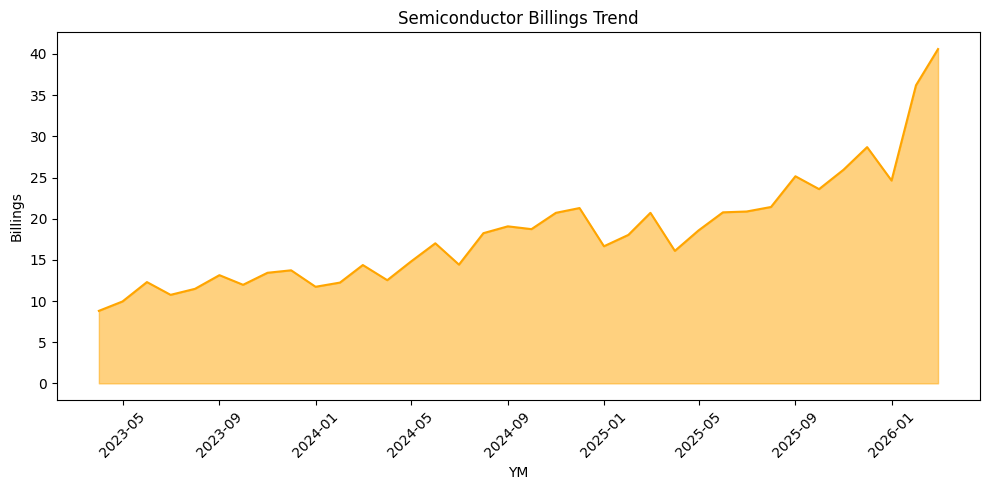

In [139]:
## Billings Trend:
plt.figure(figsize=(10,5))
plt.fill_between(final['YM'], final['Value_num'], color='orange', alpha=0.5)
plt.plot(final['YM'], final['Value_num'], label='Semiconductor Billings', color='orange')

plt.title("Semiconductor Billings Trend")
plt.xlabel("YM")
plt.ylabel("Billings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

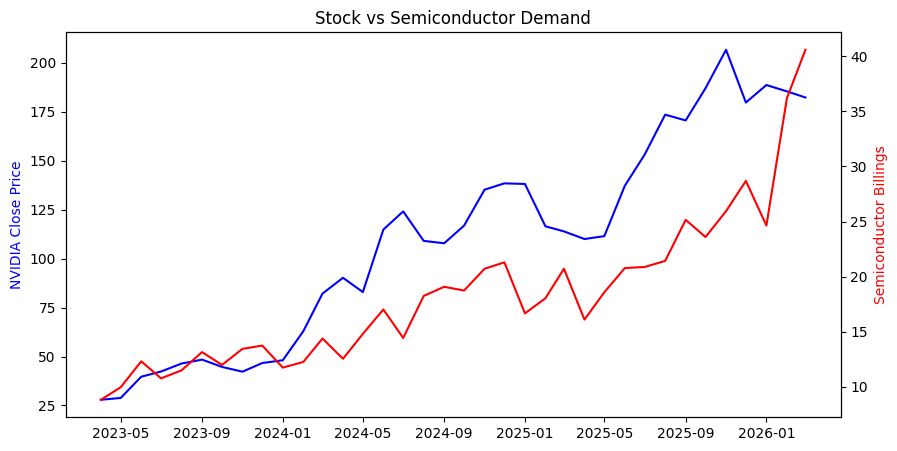

In [140]:
## Dual axis:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(final['YM'], final['Close'], color='blue')
ax1.set_ylabel('NVIDIA Close Price', color='blue')

ax2 = ax1.twinx() # second y-axis sharing the same x-axis => plots billings (different scale) alongside Close.
ax2.plot(final['YM'], final['Value_num'], color='red')
ax2.set_ylabel('Semiconductor Billings', color='red')

plt.title("Stock vs Semiconductor Demand")
plt.show()

# Allows for between-parameter (y-axis) comparisons.

### 4a. Seasonal Decomposition = breaking into smaller meaningful chunks

In [141]:
# Components: Trend (long-term direction), Seasonality (repeating patterns), and Residuals (random noise).

final['Date_x'] = pd.to_datetime(final['Date_x']) # ensures Date is in datetime format for plotting.
final = final.sort_values('Date_x') # sorts the dataframe by date in ascending order.

final.set_index('Date_x', inplace=True) # date is now index.


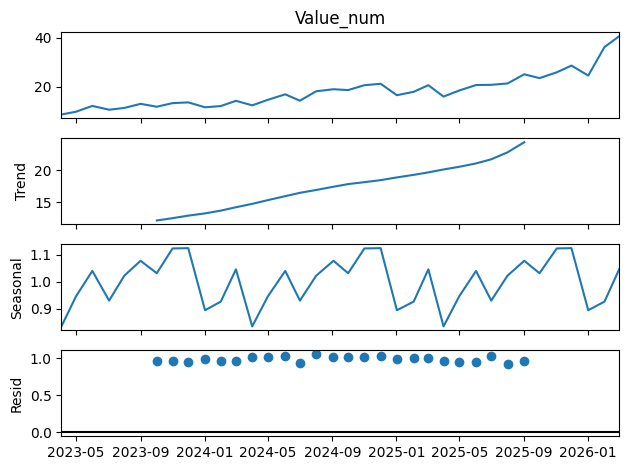

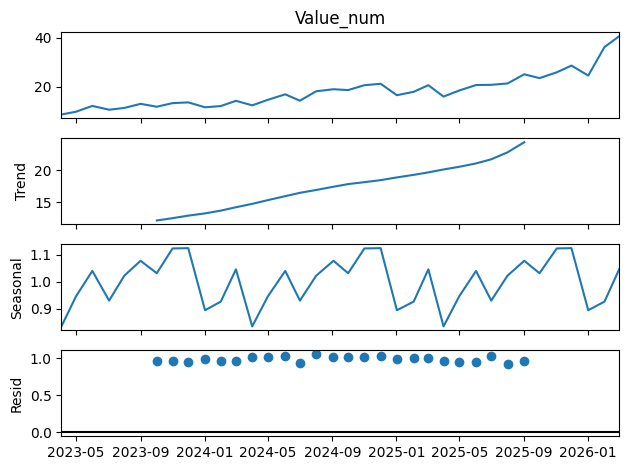

In [142]:
# Decomposition
## for the SIA data of Value_num, which is monthly and has a clear seasonal pattern.

sia_result = seasonal_decompose( # splits the series into trend + seasonal + residual components
    final['Value_num'], # the series being decomposed (semiconductor billings)
    model = 'multiplicative', # components multiply (trend * seasonal * resid); used when seasonal swings grow with the trend
    period=12 # length of one seasonal cycle: 12 => yearly pattern in monthly data
)

sia_result.plot() # plots the original series + the 3 extracted components stacked


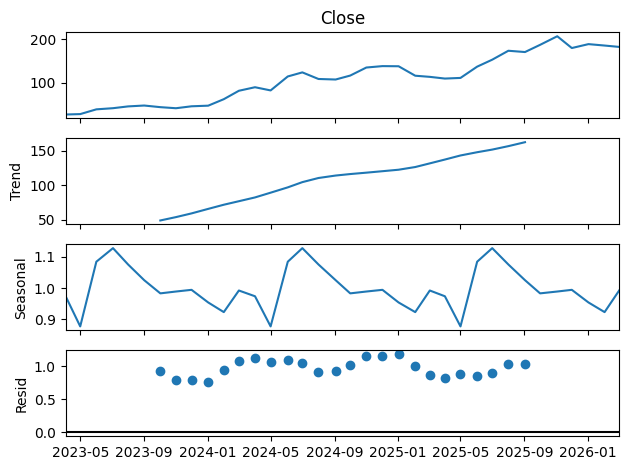

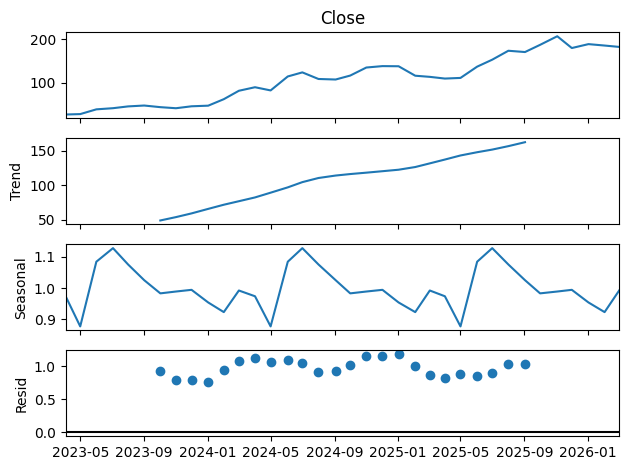

In [143]:
## for NVIDIA stok data:
nvda_result = seasonal_decompose(
    final['Close'],
    model='multiplicative',
    period=12
)

nvda_result.plot()

**Why `multiplicative` (not `additive`)?**

- **Additive**: $y_t = T_t + S_t + R_t$ — seasonal swings stay a **constant size** over time.
- **Multiplicative**: $y_t = T_t \times S_t \times R_t$ — seasonal swings **scale with the level** of the series.

(where $T_t$ = trend, $S_t$ = seasonal, $R_t$ = residual)

Billings trend upward and their seasonal swings grow with that level => multiplicative fits better.


**The three components:**

- **Trend ($T_t$)** — the long-term direction of the series (overall rise or fall), stripped of short-term wiggles.
- **Seasonal ($S_t$)** — the repeating cycle of fixed length (here the yearly pattern from `period=12`).
- **Residual ($R_t$)** — whatever is left after removing trend and seasonal: the irregular "noise" the model can't explain.

The aim is **not** to minimise the residual by choice — it's a <u>diagnostic</u>, not a knob. A good decomposition leaves a residual that is small and **patternless** (random, hovering around 1 for multiplicative). Leftover structure in the residual means the trend/seasonal fit missed something.


### Best technique for decomposition: 
#### STL Decomposition: Seasonal-Trend decomposition using LOESS (STL)

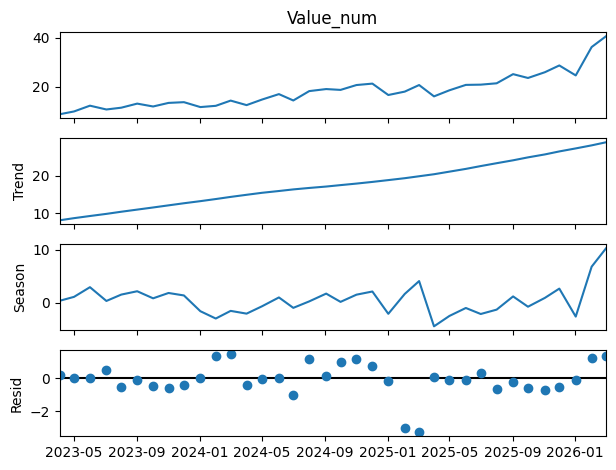

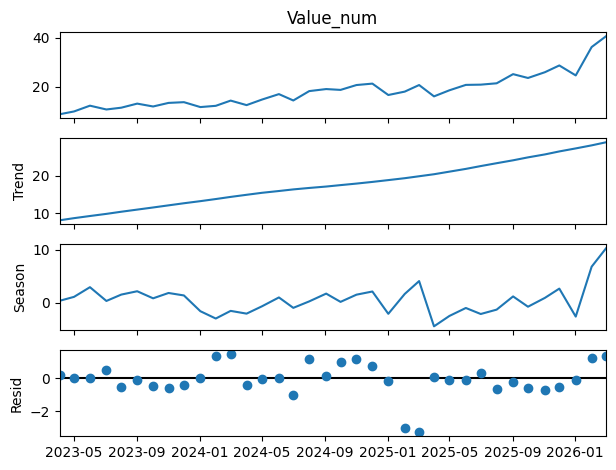

In [151]:
# STL Decomposition: Seasonal-Trend decomposition using LOESS (STL)
## Splits the series into trend + seasonal + residual (like seasonal_decompose),
## but uses LOESS smoothing => the seasonal shape can slowly change over time and it handles outliers better.

## >Therefore, seasonality does not have to be a strictly repeating pattern, and can change over time (e.g. due to changing market conditions).

stl_sia = STL(final['Value_num'], period=12).fit()
stl_sia.plot()

In [82]:
#final.isnull().sum()
#final.head()
final.shape

(36, 32)